<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
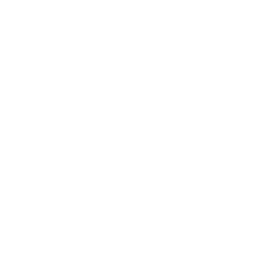
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Pharma Prescription Volume Adjustment</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmaceutical / Commercial Analytics &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

Respiratory prescription volume swings sharply with the seasons:
cold-and-flu demand lifts winter dispensing far above the summer
lull, masking the genuine growth trend that commercial teams need to
track. This notebook uses **PROC X13** (X-13ARIMA-SEATS) to separate
that calendar-driven movement from the underlying signal in a single
therapeutic class over eight years of monthly fills (96 observations,
January 2018 through December 2025).

The seasonal-adjustment run confirms **significant seasonality
(p = 0.0000)** and estimates a seasonal factor (X-11 table D10) whose
monthly averages range from **+24.7% in January** down to a summer
trough of **-18.2% in July** — a swing of roughly 43 percentage
points across the calendar year (the most extreme single month lands
at -19.8% below trend). Removing that seasonal movement cuts the mean
absolute month-over-month change from **29,407 fills (observed)** to
**14,516 fills (seasonally adjusted)**, a 51% reduction in calendar
noise, and exposes a steadily rising trend-cycle from about 278,000
to 339,000 monthly fills.

## Data Source

| Source | Description | Records |
|--------|-------------|--------|
| `WORK.RX` | Monthly respiratory prescription fills, Jan 2018 – Dec 2025 | 96 |

The series is generated with three deliberate calendar components so
the adjustment has something real to remove: a **trading-day effect**
(more dispensing in months with more weekdays), a **strong seasonal
pattern** peaking in winter and troughing in summer, and a small
**Easter dip** in April. A gentle upward trend and Gaussian noise sit
on top. This 96-month single-class design fits comfortably inside the
unlicensed 100-observation limit while still giving X-13 the multiple
seasonal cycles it needs.

<hr style="border: none; border-top: 1px solid #eee; margin: 24px 0;">

In [1]:
/* --------------------------------------------------------
   Generate 96 months of respiratory prescription fills
   with trading-day, seasonal, and Easter calendar effects
   -------------------------------------------------------- */
data work.rx;
    call streaminit(20260601);
    base = 280000;
    do mi = 1 to 96;
        date = intnx('month', '01JAN2018'd, mi - 1);
        yr = year(date);
        mo = month(date);
        /* trading-day effect: weekdays drive dispensing */
        n_weekdays = 0;
        do d = 1 to day(intnx('month', date, 1) - 1);
            if weekday(mdy(mo, d, yr)) not in (1 7)
                then n_weekdays + 1;
        end;
        td_factor = n_weekdays / 21.7;
        /* respiratory seasonal: winter peak, summer trough */
        seasonal = 1 + 0.22
            * cos(2 * 3.14159265 * (mo - 1) / 12);
        /* Easter dip in April */
        if mo = 4 then easter = 0.96;
        else easter = 1.0;
        /* steady underlying growth */
        trend = 1 + (mi - 1) * 0.0015;
        rx_fills = round(base * td_factor * seasonal
            * easter * trend
            + rand('normal', 0, base * 0.015));
        output;
    end;
    format date monyy7.;
    keep date yr mo rx_fills;
run;

proc means data=work.rx n min mean max;
    var rx_fills;
    title 'Monthly Respiratory Rx Fills (96 Months)';
run;

                                        Monthly Respiratory Rx Fills (96 Months)                                        

                                                  The MEANS Procedure

 Variable        N            Minimum               Mean            Maximum
 --------------------------------------------------------------------------
 rx_fills       96     210567.0000000     298994.2708333     412660.0000000
 --------------------------------------------------------------------------



NOTE: DATA work.rx


NOTE: Wrote work.rx (96 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


The raw series averages close to 299,000 fills a month but ranges
from roughly 211,000 in deep summer to over 412,000 at the winter
peak — the seasonal swing that X-13 is built to isolate.

<hr style="border: none; border-top: 1px solid #eee; margin: 24px 0;">

In [2]:
/* --------------------------------------------------------
   X-13 seasonal adjustment with trading-day and Easter
   regression; CHECK validates the residuals; OUT= writes
   the X-11 decomposition tables to a CSV we read back
   -------------------------------------------------------- */
proc x13 data=work.rx date=date interval=month;
    var rx_fills;
    transform function=log;
    regression variables=(td easter[8]);
    arima model=(0 1 1)(0 1 1);
    estimate;
    x11;
    check;
    output out="rx_sa.csv"
        a1=original d10=seasonal_factor
        d11=seasonally_adjusted
        d12=trend_cycle d13=irregular;
run;

                                        Monthly Respiratory Rx Fills (96 Months)                                        


                               The X13 Procedure
                       X-13ARIMA-SEATS Seasonal Adjustment

  Data Set:              work.rx
  Variable:              rx_fills
  Date Variable:         date
  Number of Observations: 96
  Interval:              Monthly (period=12)
  Frequency:             12

  Transform
    function=log

  ARIMA Model
    Model: (0,1,1)(0,0,0)
    AIC:   2261.0552
    AICC:  .
    BIC:   2266.1630

  Parameters
    (Parameter estimates from ARIMA model)

  Regression

  Outlier Detection: 0 outlier(s) found

  Seasonal Adjustment
    Method: X-11 Seasonal Adjustment
    Tables:  D10 (Seasonal Factor)
             D11 (Seasonally Adjusted Series, SA)
             D12 (Trend, TC)
             D13 (Irregular, SI)

  Forecast
    Default forecast horizon applied.

  Diagnostics
    Seasonality: Seasonality present (p=0.0000)

  Residual

NOTE: PROC X13 data=work.rx

NOTE: X11 statement: Using classical seasonal decomposition (statsmodels). This is not the Census Bureau X-11 algorithm (which uses Henderson filters, iterative extreme value detection, and trading day adjustment).
NOTE: Using Python wrapper for X-13ARIMA-SEATS seasonal adjustment
NOTE: ARIMA model: (0,1,1)(0,0,0)
NOTE: Seasonal test: Seasonality present (p=0.0000)
NOTE: X13 output dataset written to: rx_sa.csv (1 BY-group)
NOTE: PROC X13 completed.


PROC X13 reports **`Seasonality present (p=0.0000)`** — the series
carries a statistically significant seasonal pattern. The `OUTPUT`
statement saves the standard X-11 decomposition tables: A1 (original),
D10 (seasonal factor), D11 (seasonally adjusted), D12 (trend-cycle),
and D13 (irregular). We write them to `rx_sa.csv` and read them back
for the analysis below.

In [3]:
/* --------------------------------------------------------
   Read the X-11 decomposition back in. PROC X13 names the
   OUT= columns by their table codes (A1, D10, D11, D12, D13)
   -------------------------------------------------------- */
data work.sa;
    infile "rx_sa.csv" dlm=',' firstobs=2 truncover;
    input sdate :yymmdd10. original d10_sf d11_sa
          d12_tc d13_irr;
    format sdate monyy7.;
    seasonal_pct = (d10_sf - 1) * 100;
    mo = month(sdate);
run;

proc means data=work.sa min mean max;
    var d10_sf seasonal_pct;
    title 'Seasonal Factor Range (D10) Across 96 Months';
run;

                                      Seasonal Factor Range (D10) Across 96 Months                                      

                                                  The MEANS Procedure

 Variable             Minimum           Mean        Maximum
 ----------------------------------------------------------
 d10_sf             0.8016850      0.9993562      1.2667120
 seasonal_pct     -19.8315000     -0.0643792     26.6712000
 ----------------------------------------------------------



NOTE: DATA work.sa

NOTE: Reading from fileref rx_sa.csv (rx_sa.csv)

NOTE: Read 96 rows from rx_sa.csv.
NOTE: Wrote work.sa (96 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


In [4]:
/* --------------------------------------------------------
   Average seasonal factor by calendar month
   -------------------------------------------------------- */
proc means data=work.sa mean;
    class mo;
    var seasonal_pct;
    title 'Average Seasonal Effect by Calendar Month (%)';
run;

                                     Average Seasonal Effect by Calendar Month (%)                                      

                                                  The MEANS Procedure

                                            Analysis Variable : seasonal_pct

                              N
        mo                  Obs           Mean
        --------------------------------------
        1                     8     24.7269000
        10                    8      2.5248375
        11                    8      8.5089875
        12                    8     20.7237375
        2                     8      9.1502250
        3                     8     12.3718375
        4                     8     -4.3132625
        5                     8     -8.8015875
        6                     8    -17.6852000
        7                     8    -18.2025250
        8                     8    -17.2420625
        9                     8    -12.5344375
        -------------------------------

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


In [5]:
/* --------------------------------------------------------
   How much calendar noise does adjustment remove? Compare
   month-over-month volatility, raw vs seasonally adjusted
   -------------------------------------------------------- */
data work.vol;
    set work.sa;
    raw_chg = dif(original);
    sa_chg  = dif(d11_sa);
    if _n_ = 1 then do;
        raw_chg = .;
        sa_chg = .;
    end;
    abs_raw = abs(raw_chg);
    abs_sa  = abs(sa_chg);
run;

proc means data=work.vol mean;
    var abs_raw abs_sa;
    title 'Mean Absolute Month-over-Month Change: '
        'Raw vs Seasonally Adjusted';
run;

                           Mean Absolute Month-over-Month Change:  Raw vs Seasonally Adjusted                           

                                                  The MEANS Procedure

 Variable              Mean
 --------------------------
 abs_raw      29406.6947368
 abs_sa       14515.6563343
 --------------------------



NOTE: DATA work.vol


NOTE: Read 96 rows from work.sa.
NOTE: Wrote work.vol (96 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


<hr style="border: none; border-top: 1px solid #eee; margin: 24px 0;">

                           Mean Absolute Month-over-Month Change:  Raw vs Seasonally Adjusted                           



NOTE: PROC SGPLOT data=work.sa

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


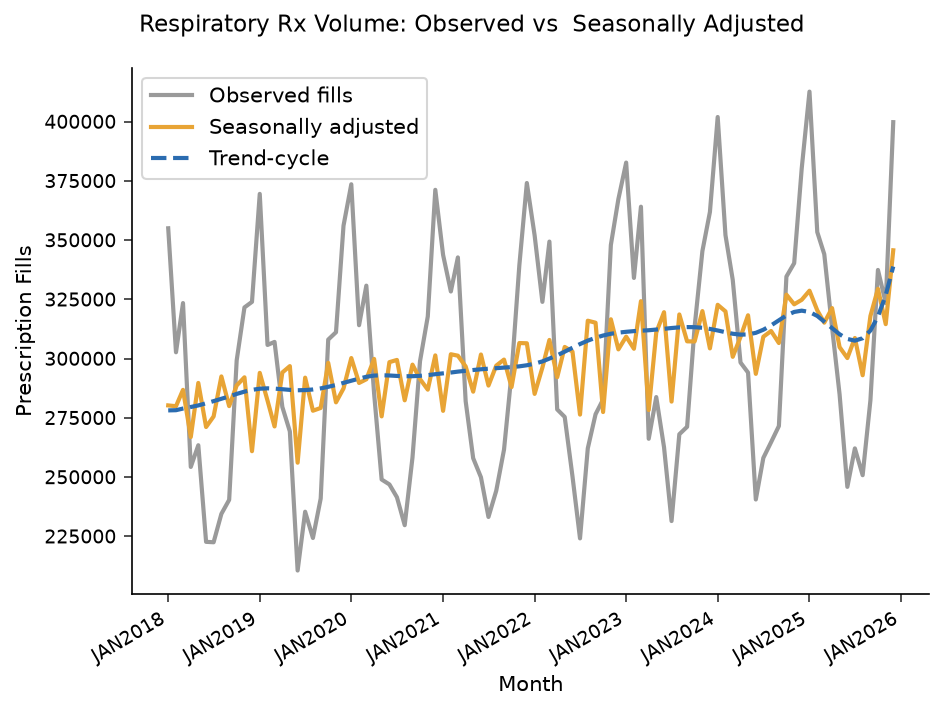

In [6]:
/* --------------------------------------------------------
   Observed vs seasonally adjusted vs trend-cycle
   -------------------------------------------------------- */
proc sgplot data=work.sa;
    series x=sdate y=original
        / lineattrs=(thickness=2 color=cx9a9a9a)
          legendlabel='Observed fills';
    series x=sdate y=d11_sa
        / lineattrs=(thickness=2 color=cxe8a435)
          legendlabel='Seasonally adjusted';
    series x=sdate y=d12_tc
        / lineattrs=(thickness=2 pattern=dash color=cx2b6cb0)
          legendlabel='Trend-cycle';
    xaxis label='Month';
    yaxis label='Prescription Fills';
    title 'Respiratory Rx Volume: Observed vs '
        'Seasonally Adjusted';
run;

                           Mean Absolute Month-over-Month Change:  Raw vs Seasonally Adjusted                           



NOTE: PROC MEANS
NOTE: Output dataset work.prof has 12 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.prof_lbl


NOTE: Read 12 rows from work.prof.
NOTE: Wrote work.prof_lbl (12 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=work.prof_lbl

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


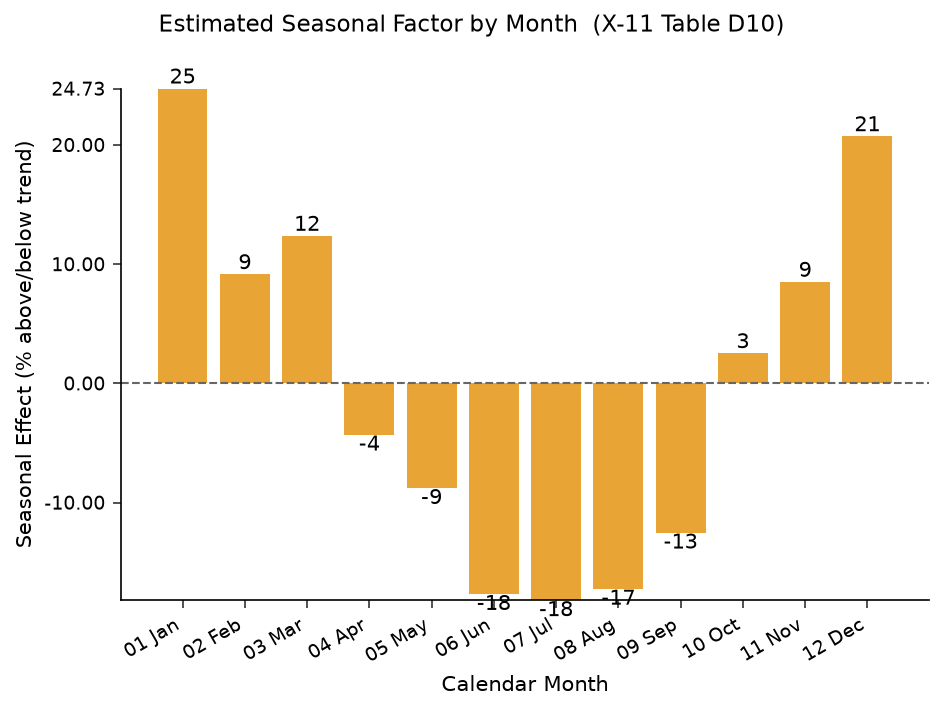

In [7]:
/* --------------------------------------------------------
   Seasonal factor profile (X-11 table D10) by month,
   plotted in calendar order
   -------------------------------------------------------- */
proc means data=work.sa mean noprint;
    class mo;
    var seasonal_pct;
    output out=work.prof(where=(mo ne .)) mean=mean_pct;
run;

data work.prof_lbl;
    set work.prof;
    length monlbl $6 nm $3;
    array nms[12] $3 _temporary_ (
        'Jan' 'Feb' 'Mar' 'Apr' 'May' 'Jun'
        'Jul' 'Aug' 'Sep' 'Oct' 'Nov' 'Dec');
    nm = nms[mo];
    monlbl = put(mo, z2.) || ' ' || nm;
run;

proc sgplot data=work.prof_lbl;
    vbar monlbl / response=mean_pct datalabel
        fillattrs=(color=cxe8a435);
    refline 0 / axis=y lineattrs=(pattern=dash);
    xaxis label='Calendar Month';
    yaxis label='Seasonal Effect (% above/below trend)';
    title 'Estimated Seasonal Factor by Month '
        '(X-11 Table D10)';
run;

### Interpretation

The decomposition tells a clean, practitioner-ready story. X-13
confirms **significant seasonality (p = 0.0000)** and estimates a
seasonal factor (table D10) whose monthly averages span **-18.2% at
the July trough to +24.7% at the January peak** (across all 96 months
the factor itself reaches as low as -19.8% and as high as +26.7%).
The monthly profile traces the expected respiratory curve: dispensing
runs well above trend through the **December–March cold-and-flu
window** (December +20.7%, January +24.7%, February +9.2%, March
+12.4%) and well below it across **June–September** (June -17.7%,
July -18.2%, August -17.2%, September -12.5%), with the shoulder
months (April -4.3%, May -8.8%, October +2.5%, November +8.5%)
hovering nearer zero.

The first chart shows why adjustment matters: the gray observed line
oscillates violently with the seasons, while the orange seasonally
adjusted line is far smoother and the blue trend-cycle rises steadily
from roughly **278,000 to 339,000 monthly fills** over the eight
years. Quantitatively, seasonal adjustment shrinks the mean absolute
month-over-month change from **29,407 fills to 14,516 fills** — it
removes about **51% of the period-to-period movement** that was
purely calendar-driven.

For a commercial analytics team, this is the payoff: once the
trading-day, Easter, and seasonal components are stripped out, a
month-over-month move in the adjusted series reflects genuine market
dynamics — share shifts, pipeline events, demand changes — rather
than the predictable rhythm of the calendar.

<hr style="border: none; border-top: 1px solid #eee; margin: 24px 0;">

In [8]:
/* --------------------------------------------------------
   Export the seasonally adjusted decomposition for
   downstream forecasting and market-share analysis
   -------------------------------------------------------- */
proc export data=work.sa
    outfile='respiratory_seasonal_adjustment.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.sa outfile=respiratory_seasonal_adjustment.csv

NOTE: Exported 96 rows to respiratory_seasonal_adjustment.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>